## Prédiction des exacerbations chez les patients asthmatiques
### 1. Contexte et Objectif

Les facteurs déclenchant les crises d'asthme (exacerbations) chez les patients sous traitement restent encore difficiles à identifier. L'objectif principal de ce projet est de développer un modèle prédictif capable d'anticiper la survenue de ces exacerbations dans l'année suivant la consultation.

Notre variable cible est donc binaire :

- 1 : Le patient risque de faire au moins une exacerbation dans l'année.
- 0 : Le patient ne présente pas de risque d'exacerbation.

### 2. Données et Méthodologie

Pour construire ce modèle, nous nous basons sur un jeu de données médicales (trainDataDC2.csv.gz).

L'algorithme qui nous a été spécifiquement assigné pour résoudre ce problème est la Forêt Aléatoire (Random Forest). C'est une méthode robuste qui combine plusieurs arbres de décision pour fournir une prédiction plus fiable.

Dans ce notebook, nous allons procéder par étapes :

- Exploration et préparation des données (gestion des valeurs manquantes, séparation des données).
- Entraînement d'un premier modèle Random Forest.
- Optimisation des paramètres de l'algorithme pour améliorer nos prédictions.
- Évaluation finale des performances (via le F1-score) et génération du fichier de prédictions demandé.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score
from sklearn.model_selection import cross_val_predict, GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline

pd.set_option("display.float_format", lambda x: "%.2f" % x)

### 3. Chargement et exploration initiale des données

La première étape consiste à importer notre jeu de données et à observer sa structure. Nous regardons un échantillon des données, le nombre de lignes et de colonnes, ainsi que le type de chaque variable.
Cela nous permet de repérer immédiatement la présence de valeurs manquantes (les fameux "NaN") que notre modèle Random Forest ne saura pas gérer tel quel. Il faudra donc les traiter par la suite.

In [2]:
path = "../data/trainDataDC2.csv.gz"
df = pd.read_csv(path)
df.sample(5)

,patid,index_age,previous_asthma_drugs,total_pre_index_cannisters_365,post_index_exacerbations365,pneumonia,sinusitis,acute_bronchitis,acute_laryngitis,upper_respiratory_infection,...,rhinitis,adherence,total_pre_index_charge,pre_asthma_days,pre_asthma_charge,pre_asthma_pharma_charge,drug_s,female,log_charges,log_asthma_charge
3142,1184659905,35.00,1.00,1.00,0,NaN,0.00,0.00,0.00,0.00,...,0.00,0.17,2876.52,1.00,250.00,35.39,0.00,1.00,NaN,3.57
13609,1328700268,41.00,1.00,0.00,0,0.00,0.00,0.00,0.00,0.00,...,NaN,0.25,NaN,1.00,669.75,NaN,1.00,0.00,6.78,5.34
4415,1248190219,41.00,1.00,0.00,9,0.00,1.00,NaN,NaN,0.00,...,0.00,0.08,NaN,0.00,0.00,22.00,0.00,1.00,11.32,3.09
5476,1268904447,52.00,1.00,1.00,0,NaN,1.00,0.00,0.00,0.00,...,0.00,0.15,18978.43,0.00,0.00,30.84,0.00,0.00,9.85,NaN
11728,1555418245,18.00,1.00,1.00,0,0.00,0.00,1.00,0.00,0.00,...,0.00,0.17,5691.53,0.00,0.00,329.08,0.00,1.00,8.65,5.80


In [3]:
df.shape

(14575, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14575 entries, 0 to 14574
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patid                           14575 non-null  int64  
 1   index_age                       13085 non-null  float64
 2   previous_asthma_drugs           13144 non-null  float64
 3   total_pre_index_cannisters_365  13131 non-null  float64
 4   post_index_exacerbations365     14575 non-null  int64  
 5   pneumonia                       13072 non-null  float64
 6   sinusitis                       13084 non-null  float64
 7   acute_bronchitis                13127 non-null  float64
 8   acute_laryngitis                13166 non-null  float64
 9   upper_respiratory_infection     13114 non-null  float64
 10  gerd                            13108 non-null  float64
 11  rhinitis                        13109 non-null  float64
 12  adherence                       

### 4. Préparation de la variable cible

Conformément aux consignes du projet, nous devons prédire si un patient va faire une exacerbation ou non, et non pas deviner le nombre exact de crises.
Nous allons donc transformer notre variable cible (post_index_exacerbations365) pour qu'elle devienne binaire :
- 0 : Aucune exacerbation.
- 1 : Une ou plusieurs exacerbations.

Nous en profitons pour compter le nombre de patients dans chaque catégorie. Cela nous permet de constater un fort déséquilibre : la grande majorité des patients n'ont pas fait d'exacerbation. C'est une information cruciale.

In [5]:
df["post_index_exacerbations365"] = df["post_index_exacerbations365"].apply(lambda x : 0 if x == 0 else 1)
df["post_index_exacerbations365"].value_counts()

post_index_exacerbations365
0    12913
1     1662
Name: count, dtype: int64

### 5. Séparation des données pour l'entraînement et le test

Avant d'entraîner le modèle, nous devons isoler ce que nous voulons prédire (la cible y) des informations qui vont nous aider à prédire (les variables explicatives X).
Lors de cette étape, nous retirons également certaines colonnes inutiles ou "tricheuses", comme l'identifiant du patient (patid) ou des variables de facturation directement liées à l'exacerbation qui fausseraient la prédiction.

Ensuite, nous coupons nos données en deux sous-ensembles :

- Un jeu d'entraînement (80%) : qui servira à l'apprentissage de l'algorithme.
- Un jeu de test (20%) : que nous gardons précieusement de côté pour évaluer les performances de notre modèle à la toute fin, sur des données qu'il n'a jamais vues.

Nous utilisons une séparation "stratifiée" pour garantir qu'il y aura la même proportion de patients avec exacerbation dans les deux jeux.

In [6]:
X = df.drop(["post_index_exacerbations365", "patid", "total_pre_index_charge", "pre_asthma_charge"], axis=1)
y = df["post_index_exacerbations365"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, shuffle=True, random_state=42)

### 6. Création du Pipeline (Imputation et Modélisation)

Notre jeu de données contient des valeurs manquantes (les "NaN"). Plutôt que de supprimer les lignes concernées au risque de perdre de l'information précieuse, nous allons les deviner intelligemment. 
Pour cela, nous utilisons un Pipeline, qui permet d'enchaîner deux étapes automatiquement :
1. L'imputation (IterativeImputer) : Cette méthode va remplacer les valeurs manquantes en se basant sur les autres variables du patient.
2. Le modèle (Random Forest) : C'est l'algorithme de classification qui va s'entraîner sur ces données complétées.

L'avantage du Pipeline est qu'il évite les erreurs de manipulation entre nos données d'entraînement et nos données de test.

In [7]:
rf_pipeline = Pipeline([
    ('imputer', IterativeImputer(max_iter=10, random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

### 7. Première optimisation des paramètres (Recherche aléatoire)

Un modèle Random Forest possède plusieurs réglages (les hyperparamètres), comme le nombre d'arbres ou leur profondeur. Les valeurs par défaut ne sont pas toujours les meilleures pour notre problème médical.

Pour trouver une bonne configuration sans que le calcul ne prenne des heures, nous utilisons une recherche aléatoire (RandomizedSearchCV). Le principe est simple :
- Nous définissons une large plage de valeurs possibles pour chaque paramètre.
- L'algorithme va tirer au sort 100 combinaisons différentes et les tester.
- Il évaluera chaque combinaison grâce à une validation croisée (pour s'assurer que le modèle est robuste) et retiendra celle qui donne le meilleur score F1.

In [8]:
rf_params= {
    'classifier__n_estimators': randint(100, 250),
    'classifier__max_depth': randint(5, 10),
    'classifier__min_samples_split': randint(2, 10),
    'classifier__min_samples_leaf': randint(1, 10),
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__class_weight': ['balanced', 'balanced_subsample', None]
}

In [9]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=100,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'classifier__class_weight': ['balanced', 'balanced_subsample', ...], 'classifier__max_depth': <scipy.stats....001C1B559B4D0>, 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': <scipy.stats....001C1B55B7100>, ...}"
,n_iter,100
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [10]:
# Sauvegarde du meilleur modèle trouvé
best_model = random_search.best_estimator_
best_params = random_search.best_params_
print(best_params)

{'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 9, 'classifier__n_estimators': 225}


### 8. Évaluation du premier modèle

Maintenant que la recherche aléatoire a trouvé une bonne configuration, nous allons tester ce modèle sur notre jeu de test (les 20% de données mises de côté). 
Nous utilisons le F1-score comme indicateur principal, car l'Accuracy (exactitude) classique est trompeuse sur des données déséquilibrées (prédire que personne ne fera d'exacerbation donnerait une bonne Accuracy, mais un modèle inutile).

In [11]:
y_pred = best_model.predict(X_test)

In [12]:
print("\n--- Meilleur Score F1 en CV : {:.4f} ---".format(random_search.best_score_))
print("\n--- Rapport de Classification sur le Test ---")
print(classification_report(y_test, y_pred))


--- Meilleur Score F1 en CV : 0.2122 ---

--- Rapport de Classification sur le Test ---
              precision    recall  f1-score   support

           0       0.90      0.62      0.73      2583
           1       0.13      0.44      0.20       332

    accuracy                           0.60      2915
   macro avg       0.51      0.53      0.46      2915
weighted avg       0.81      0.60      0.67      2915



In [13]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred)*100:.2f}%")

Accuracy: 59.59%
F1-Score: 19.86%
Recall: 43.98%


### 9. Ajustement du seuil de décision

Par défaut, l'algorithme prédit une exacerbation (1) si la probabilité dépasse 50% (0.50). Cependant, comme les exacerbations sont rares dans nos données, ce seuil strict nous fait rater beaucoup de patients à risque. 

Pour corriger cela, nous créons une fonction qui va chercher le seuil optimal directement sur nos probabilités d'entraînement afin de maximiser notre F1-score. Nous appliquerons ensuite ce seuil sur-mesure à nos données de test pour voir notre vraie performance.

In [14]:
def best_threshold(y_true, y_proba):
    best_t = 0.5
    best_f1 = 0
    for t in np.arange(0.1, 0.9, 0.01):
        y_pred = (y_proba >= t).astype(int)
        f1 = f1_score(y_true, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1

# On calcule les probabilités sur l'échantillon d'ENTRAÎNEMENT via validation croisée
y_proba_train_cv = cross_val_predict(best_model, X_train, y_train, cv=cv_strategy, method='predict_proba')[:, 1]

# On cherche le meilleur seuil avec notre fonction sur y_train
best_t_cv, best_f1_cv = best_threshold(y_train, y_proba_train_cv)
print(f"Meilleur seuil sur le Train set : {best_t_cv}")

# 3. On évalue la VRAIE performance sur le Test avec ce seuil
y_proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test_opti = (y_proba_test >= best_t_cv).astype(int)

print(f"Vrai F1-Score sur le Test set : {f1_score(y_test, y_pred_test_opti)*100:.2f}%")

Meilleur seuil sur le Train set : 0.46999999999999986
Vrai F1-Score sur le Test set : 20.75%


### 10. Interprétation : Importance des variables

L'un des grands avantages de la Forêt Aléatoire est qu'elle n'est pas une "boîte noire" totale. Elle peut nous indiquer quelles informations (variables) ont été les plus utiles pour prendre ses décisions. 
Nous allons visualiser cela sous forme de graphique pour comprendre quels facteurs pèsent le plus dans le risque d'exacerbation de l'asthme.

C:\Users\Ce PC\AppData\Local\Temp\ipykernel_7512\579271799.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Variable', data=df_importances, palette='viridis')


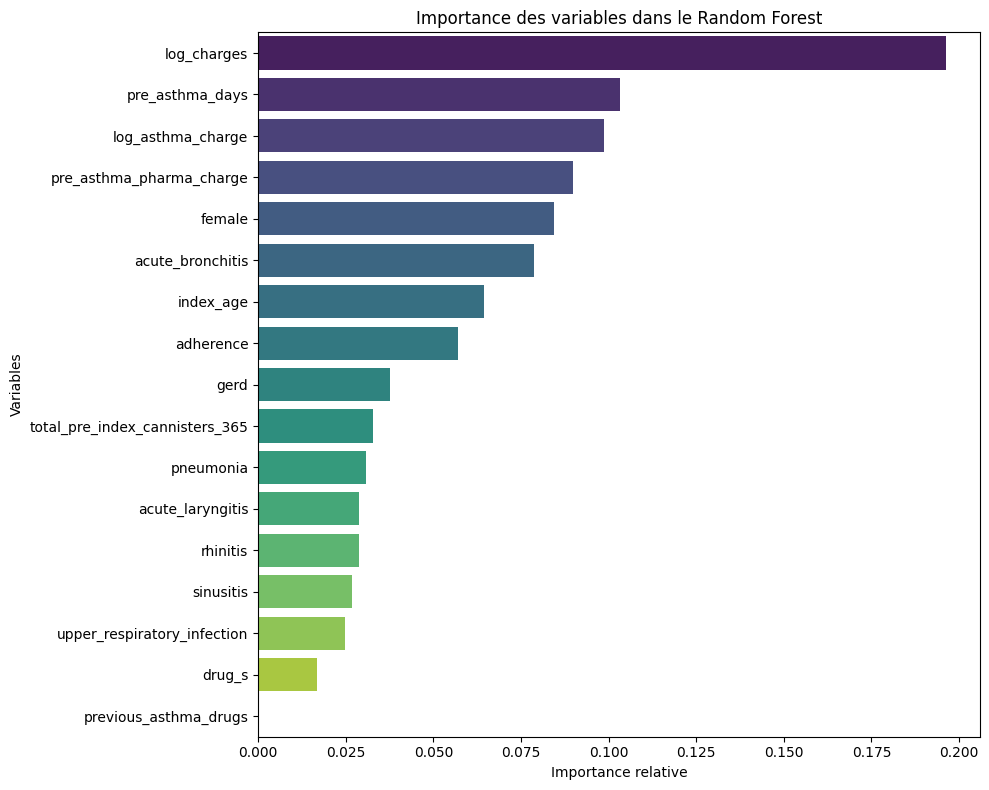

In [15]:
# Récupération des importances depuis le meilleur modèle
importances = best_model.named_steps['classifier'].feature_importances_
colonnes = X_train.columns

# Création d'un DataFrame pour faciliter l'affichage
df_importances = pd.DataFrame({
    'Variable': colonnes,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Affichage graphique
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Variable', data=df_importances, palette='viridis')
plt.title('Importance des variables dans le Random Forest')
plt.xlabel('Importance relative')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

### 11. Affinage de l'optimisation (Recherche sur Grille)

La recherche aléatoire nous a donné une très bonne zone de réglage. Pour aller encore plus loin et grappiller de la performance, nous utilisons maintenant une "Grid Search" (Recherche sur grille exhaustive). 
Nous ciblons des valeurs très proches des meilleurs paramètres trouvés précédemment, et nous testons cette fois-ci absolument toutes les combinaisons possibles de cette zone restreinte.

In [16]:
param_grid = {
    'classifier__n_estimators': [200, 225, 250],
    'classifier__max_depth': [4, 5],
    'classifier__min_samples_split': [8, 9, 10],
    'classifier__min_samples_leaf': [1, 2, 3],
    'classifier__max_features': ['sqrt'],
    'classifier__class_weight': ['balanced_subsample']
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Nouveaux meilleurs paramètres :", grid_search.best_params_)
print("Nouveau meilleur F1 CV :", grid_search.best_score_)
best_model_grid = grid_search.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Nouveaux meilleurs paramètres : {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 4, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 9, 'classifier__n_estimators': 250}
Nouveau meilleur F1 CV : 0.2159577261484588


In [17]:
# On calcule les probabilités sur l'échantillon d'ENTRAÎNEMENT via validation croisée
y_proba_train_cv = cross_val_predict(best_model_grid, X_train, y_train, cv=cv_strategy, method='predict_proba')[:, 1]

# On cherche le meilleur seuil avec notre fonction sur y_train
best_t_cv, best_f1_cv = best_threshold(y_train, y_proba_train_cv)
print(f"Meilleur seuil (calculé sur le Train) : {best_t_cv}")

# 3. On évalue la VRAIE performance sur le Test avec ce seuil
y_proba_test = best_model_grid.predict_proba(X_test)[:, 1]
y_pred_test_opti = (y_proba_test >= best_t_cv).astype(int)

print(f"Vrai F1-Score sur le Test : {f1_score(y_test, y_pred_test_opti)*100:.2f}%")

Meilleur seuil (calculé sur le Train) : 0.48999999999999977
Vrai F1-Score sur le Test : 20.37%


### 12. Modèle final Forêt Aléatoire et limites

Nous ajustons notre grille de recherche une toute dernière fois autour des meilleures valeurs trouvées pour être certains d'avoir la configuration la plus optimale possible pour notre Forêt Aléatoire. 

Si l'on observe de près les résultats, on remarque un phénomène très classique : à force d'optimiser à l'extrême sur les données d'entraînement, le score sur les données de test peut stagner voire très légèrement baisser. C'est ce qu'on appelle un léger surapprentissage. Notre modèle reste néanmoins performant et très stable.

In [18]:
param_grid_final = {
    'classifier__n_estimators': [250, 275],
    'classifier__max_depth': [3, 4, 5], 
    'classifier__min_samples_split': [8, 9, 10],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt'],
    'classifier__class_weight': ['balanced_subsample']
}

grid_search_final = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_final,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_final.fit(X_train, y_train)

print("Nouveaux meilleurs paramètres :", grid_search_final.best_params_)
print("Nouveau meilleur F1 CV :", grid_search_final.best_score_)
best_model_final = grid_search_final.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Nouveaux meilleurs paramètres : {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 3, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 8, 'classifier__n_estimators': 275}
Nouveau meilleur F1 CV : 0.21720696950034996


In [19]:
# On calcule les probabilités sur l'échantillon d'ENTRAÎNEMENT via validation croisée
y_proba_train_cv = cross_val_predict(best_model_final, X_train, y_train, cv=cv_strategy, method='predict_proba')[:, 1]

# On cherche le meilleur seuil avec notre fonction sur y_train
best_t_cv, best_f1_cv = best_threshold(y_train, y_proba_train_cv)
print(f"Meilleur seuil (calculé sur le Train) : {best_t_cv}")

# On évalue la VRAIE performance sur le Test avec ce seuil
y_proba_test = best_model_final.predict_proba(X_test)[:, 1]
y_pred_test_opti = (y_proba_test >= best_t_cv).astype(int)

print(f"Vrai F1-Score sur le Test : {f1_score(y_test, y_pred_test_opti)*100:.2f}%")

Meilleur seuil (calculé sur le Train) : 0.48999999999999977
Vrai F1-Score sur le Test : 20.47%


In [20]:
print(classification_report(y_test, y_pred_test_opti))

              precision    recall  f1-score   support

           0       0.90      0.47      0.62      2583
           1       0.12      0.58      0.20       332

    accuracy                           0.49      2915
   macro avg       0.51      0.53      0.41      2915
weighted avg       0.81      0.49      0.57      2915



### Choix du modèle final Forêt Aléatoire et Génération des résultats

En comparant notre premier modèle (issu de la recherche aléatoire) avec nos deux modèles affinés (issus des recherches sur grille), nous constatons un phénomène intéressant. Si l'optimisation poussée a bien amélioré le score sur les données d'entraînement, elle a légèrement fait baisser notre F1-score sur les données de test (passant de 20.75% à 20.47%).

Cela indique que nos dernières optimisations ont provoqué un léger surapprentissage (overfitting). Par conséquent, nous décidons de conserver notre tout premier modèle comme modèle final pour la Forêt Aléatoire, car c'est lui qui généralise le mieux face à de nouvelles données.

Conformément aux attentes du projet, nous allons utiliser ce modèle gagnant pour générer nos prédictions finales sur le jeu de test et les exporter. Nous allons créer le fichier de résultat attendu au format .csv, qui se composera uniquement de l'identifiant du patient (patid) et de la prédiction associée (1 ou 0).

In [21]:
# On recalcule les prédictions avec le PREMIER modèle (best_model)
# et le seuil optimal calculé à l'étape de la cellule 14 (environ 0.47)
seuil_optimal = 0.47 
y_proba_test_final = best_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_test_final >= seuil_optimal).astype(int)

# On récupère les identifiants (patid) correspondants dans le dataframe d'origine
# X_test a conservé les mêmes index (numéros de ligne) que df
patids_test = df.loc[X_test.index, 'patid']

df_resultats = pd.DataFrame({
    'patid': patids_test,
    'prediction': y_pred_final
})

fichier_sortie = 'predictions_exacerbations.csv'
df_resultats.to_csv(fichier_sortie, index=False)

### 13. Modèle Bonus : Gradient Boosting (XGBoost)

Pour tenter d'obtenir la meilleure performance possible, nous allons comparer notre Forêt Aléatoire avec un autre algorithme très puissant : XGBoost. 
Contrairement à la Forêt Aléatoire qui crée des arbres indépendamment les uns des autres, XGBoost crée des arbres à la suite, où chaque nouvel arbre essaie de corriger les erreurs du précédent.

Avant de lancer le modèle, nous calculons le ratio exact de déséquilibre de nos classes (le paramètre `scale_pos_weight`). Nous le fournissons à XGBoost pour qu'il pénalise fortement les erreurs faites sur la classe minoritaire (les patients faisant des exacerbations).

In [22]:
ratio_classes = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio pour scale_pos_weight : {ratio_classes:.2f}")

Ratio pour scale_pos_weight : 7.77


In [23]:
xgb_pipeline = Pipeline([
    ('imputer', IterativeImputer(random_state=42)),
    ('classifier', xgb.XGBClassifier(
        scale_pos_weight=ratio_classes,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    ))
])

In [24]:
xgb_params = {
    'classifier__n_estimators': randint(100, 300),
    'classifier__learning_rate': uniform(0.01, 0.19), 
    'classifier__max_depth': randint(3, 6),
    'classifier__min_child_weight': randint(1, 6), 
    'classifier__gamma': uniform(0, 2), 
    'classifier__subsample': uniform(0.7, 0.3), 
    'classifier__colsample_bytree': uniform(0.7, 0.3), 
    'classifier__reg_alpha': [1e-3, 0.1, 1, 10],
    'classifier__reg_lambda': [1e-3, 0.1, 1, 10]
}

In [25]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=30,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Meilleurs paramètres XGBoost :", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleurs paramètres XGBoost : {'classifier__colsample_bytree': np.float64(0.8900589132282684), 'classifier__gamma': np.float64(1.071549368149517), 'classifier__learning_rate': np.float64(0.02715505631033758), 'classifier__max_depth': 3, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 223, 'classifier__reg_alpha': 1, 'classifier__reg_lambda': 0.1, 'classifier__subsample': np.float64(0.9087438420372645)}


### 14. Évaluation de XGBoost et ajustement du seuil

Une fois les meilleurs hyperparamètres trouvés, nous appliquons la même rigueur que pour la Forêt Aléatoire : nous ne nous contentons pas du seuil de décision par défaut de 0.50. 

Nous utilisons notre fonction pour calculer le seuil optimal sur nos probabilités d'entraînement afin de maximiser le F1-score. Ensuite, nous appliquons ce seuil spécifique à nos données de test pour obtenir notre performance réelle et définitive avec XGBoost.

In [26]:
y_proba_train_xgb = cross_val_predict(best_xgb, X_train, y_train, cv=cv_strategy, method='predict_proba')[:, 1]

best_t_xgb, best_f1_train_xgb = best_threshold(y_train, y_proba_train_xgb)
print(f"Meilleur seuil XGBoost sur le Train set : {best_t_xgb:.4f}")

y_proba_test_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_test_xgb = (y_proba_test_xgb >= best_t_xgb).astype(int)
print(f"Vrai F1-Score sur le Test set : {f1_score(y_test, y_pred_test_xgb)*100:.2f}%")

print(classification_report(y_test, y_pred_test_xgb))

Meilleur seuil XGBoost sur le Train set : 0.4800
Vrai F1-Score sur le Test set : 20.50%
              precision    recall  f1-score   support

           0       0.90      0.49      0.64      2583
           1       0.13      0.57      0.21       332

    accuracy                           0.50      2915
   macro avg       0.51      0.53      0.42      2915
weighted avg       0.81      0.50      0.59      2915



### 15. Interprétation : Importance des variables (XGBoost)

Tout comme la Forêt Aléatoire, XGBoost permet de visualiser quelles informations ont le plus influencé ses prédictions. 

Nous générons ce graphique pour observer quels facteurs de risque ressortent avec cet algorithme. Il est toujours intéressant de vérifier si les deux modèles s'accordent sur les variables médicales les plus déterminantes pour anticiper une crise d'asthme.

C:\Users\Ce PC\AppData\Local\Temp\ipykernel_7512\3929781453.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Variable', data=df_imp_xgb, palette='magma')


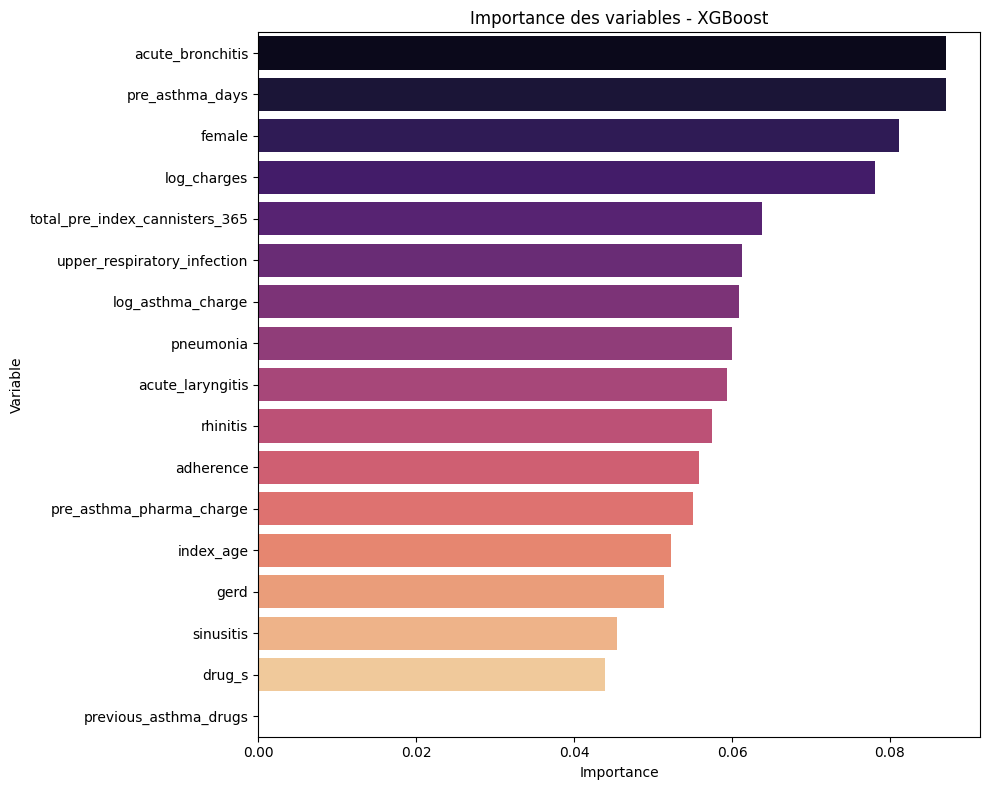

In [27]:
# Récupération des importances XGBoost
xgb_importances = best_xgb.named_steps['classifier'].feature_importances_
df_imp_xgb = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': xgb_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Variable', data=df_imp_xgb, palette='magma')
plt.title('Importance des variables - XGBoost')
plt.tight_layout()
plt.show()

### 16. Comparaison finale des performances

Nous avons maintenant nos deux modèles optimisés : la Forêt Aléatoire (notre modèle de base) et XGBoost (notre modèle bonus). 

Pour visualiser clairement quel algorithme a le mieux réussi à identifier les patients à risque, nous regroupons leurs résultats de test (F1-Score, Rappel et Exactitude) dans un tableau récapitulatif et un graphique à barres. Le modèle présentant le meilleur F1-score sur les données de test sera considéré comme le plus performant.

Comparaison des Modèles
          Modèle  F1-Score Test  Recall Test  Accuracy Test
0  Random Forest         0.2075       0.6446         0.4391
1        XGBoost         0.2050       0.5663         0.4998


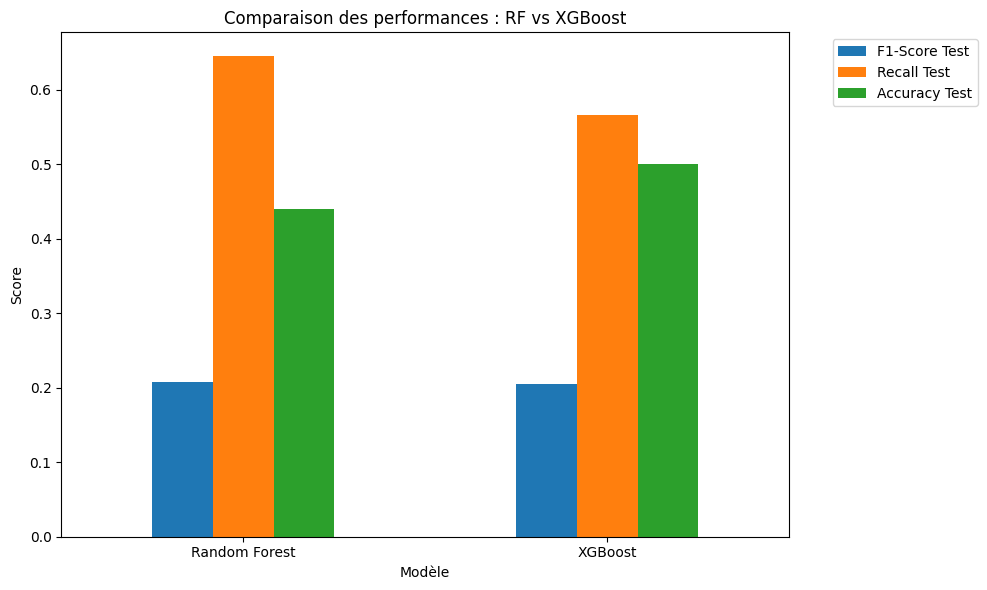

In [28]:
pd.set_option("display.float_format", lambda x: "%.4f" % x)

# Recalcul explicite des prédictions pour Random Forest
y_proba_train_cv = cross_val_predict(best_model, X_train, y_train, cv=cv_strategy, method='predict_proba')[:, 1]

best_t_cv, _ = best_threshold(y_train, y_proba_train_cv)

y_proba_test_rf = best_model.predict_proba(X_test)[:, 1]
y_pred_test_opti = (y_proba_test_rf >= best_t_cv).astype(int)

# Recalcul explicite des prédictions pour XGBoost
y_proba_test_xgb_final = best_xgb.predict_proba(X_test)[:, 1]
y_pred_test_xgb = (y_proba_test_xgb_final >= best_t_xgb).astype(int)

# Calcul des métriques pour Random Forest
metrics_rf = {
    'Modèle': 'Random Forest',
    'F1-Score Test': f1_score(y_test, y_pred_test_opti),
    'Recall Test': recall_score(y_test, y_pred_test_opti),
    'Accuracy Test': accuracy_score(y_test, y_pred_test_opti)
}

# Calcul des métriques pour XGBoost
metrics_xgb = {
    'Modèle': 'XGBoost',
    'F1-Score Test': f1_score(y_test, y_pred_test_xgb),
    'Recall Test': recall_score(y_test, y_pred_test_xgb),
    'Accuracy Test': accuracy_score(y_test, y_pred_test_xgb)
}

# Création et affichage du tableau comparatif
df_comparaison = pd.DataFrame([metrics_rf, metrics_xgb])
print("Comparaison des Modèles")
print(df_comparaison.round(4))

# Visualisation
df_comparaison.set_index('Modèle').plot(kind='bar', figsize=(10, 6))
plt.title('Comparaison des performances : RF vs XGBoost')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 17.  Conclusion générale

Ce projet avait pour but de prédire les exacerbations d'asthme à partir de données médicales complexes. Après avoir traité les valeurs manquantes et optimisé nos algorithmes, voici les résultats sur notre jeu de test :
- Random Forest : F1-Score de 20.75% et Rappel de 64.46%.
- XGBoost : F1-Score de 20.50% et Rappel de 56.63%.

Le modèle Random Forest est très légèrement meilleur. Dans notre contexte, notre objectif principal est de détecter les patients à risque (les "1") et non les patients sains (les "0"). Avec un rappel nettement supérieur (près de 65% des malades détectés), la Forêt Aléatoire réussit mieux à identifier ces cas critiques. 

Il faut toutefois souligner que les performances globales de nos deux modèles restent faibles. Cette difficulté s'explique principalement par le très fort déséquilibre de nos données (les exacerbations étant extrêmement rares). Malgré nos méthodes pour compenser ce problème (ajustement des poids et des seuils de probabilité), ce déséquilibre massif rend la détection des "1" particulièrement difficile pour les algorithmes.